# EcoData – Pipeline Completo Unidad 1
## Sistema de Alerta Temprana de Calidad del Aire – Juliaca
**Arquitectura:** Lambda (Batch)  
**Estudiante:** [Alahin Reyme Ticona Veliz]  
**Estudiante:** [VARGAS MARICHI lanzeloth]
**Curso:** Big Data – Proyecto Sello

Celda 1 – Configuración

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import os

spark = (SparkSession.builder
    .appName("EcoData-U1-Pipeline")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate())

print("Spark versión:", spark.version)

# Rutas
DATA = "/opt/ecodata/data"
ARTIFACTS = "/opt/ecodata/artifacts"
os.makedirs(ARTIFACTS, exist_ok=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/11 05:49:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark versión: 4.2.0


Celda 2 – Extracción y limpieza CLIMA (Bronze → Silver)

In [2]:
# Cargar y limpiar clima
pdf_clima = pd.read_csv(f"{DATA}/juliaca_clima_historico.csv", skiprows=2)
pdf_clima.columns = [c.replace(" (°C)","").replace(" (km/h)","").replace(" (°)","").replace(" (%)","").replace(" ","_").lower() 
                     for c in pdf_clima.columns]

df_clima = spark.createDataFrame(pdf_clima)
df_clima = (df_clima
    .withColumn("time", to_timestamp("time"))
    .withColumn("temperature_2m", col("temperature_2m").cast("double"))
    .withColumn("wind_speed_10m", col("wind_speed_10m").cast("double"))
    .withColumn("wind_direction_10m", col("wind_direction_10m").cast("double"))
    .withColumn("relative_humidity_2m", col("relative_humidity_2m").cast("double"))
    .select("time", "temperature_2m", "wind_speed_10m", "wind_direction_10m", "relative_humidity_2m")
)

print("Clima limpio:", df_clima.count())
df_clima.printSchema()

/usr/local/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:687: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
[Stage 0:>                                                        (0 + 20) / 20]

Clima limpio: 26304
root
 |-- time: timestamp (nullable = true)
 |-- temperature_2m: double (nullable = true)
 |-- wind_speed_10m: double (nullable = true)
 |-- wind_direction_10m: double (nullable = true)
 |-- relative_humidity_2m: double (nullable = true)



Celda 3 – Controles de calidad (nulos + duplicados + filtrado)

In [3]:
print("=== NULOS ===")
df_clima.select([count(when(col(c).isNull(), c)).alias(c) for c in df_clima.columns]).show()

print("=== DUPLICADOS ===")
print("Duplicados por time:", df_clima.groupBy("time").count().filter("count > 1").count())

df_clima = df_clima.dropDuplicates(["time"])
df_clima = df_clima.filter(
    col("temperature_2m").between(-20, 40) &
    col("wind_speed_10m").between(0, 100) &
    col("relative_humidity_2m").between(0, 100)
)
print("Clima después de calidad:", df_clima.count())

=== NULOS ===
+----+--------------+--------------+------------------+--------------------+
|time|temperature_2m|wind_speed_10m|wind_direction_10m|relative_humidity_2m|
+----+--------------+--------------+------------------+--------------------+
|   0|             0|             0|                 0|                   0|
+----+--------------+--------------+------------------+--------------------+

=== DUPLICADOS ===
Duplicados por time: 0
Clima después de calidad: 26304


Celda 4 – Escritura Gold (Parquet particionado) + verificación

In [4]:
df_gold = (df_clima
    .withColumn("año", year("time"))
    .withColumn("mes", month("time"))
)

ruta_gold = f"{ARTIFACTS}/juliaca_clima_particionado"
df_gold.write.mode("overwrite").partitionBy("año", "mes").parquet(ruta_gold)

df_leido = spark.read.parquet(ruta_gold)
print(f"Ida y vuelta: original={df_clima.count()} | leído={df_leido.count()}")

print("\n=== PartitionFilters ===")
df_leido.filter((col("año")==2024) & (col("mes")==3)).explain(True)

[Stage 28:>                                                       (0 + 18) / 18]

Ida y vuelta: original=26304 | leído=26304

=== PartitionFilters ===
== Parsed Logical Plan ==
'Filter 'and('`=`('año, 2024), '`=`('mes, 3))
+- Relation [time#156,temperature_2m#157,wind_speed_10m#158,wind_direction_10m#159,relative_humidity_2m#160,año#161,mes#162] parquet

== Analyzed Logical Plan ==
time: timestamp, temperature_2m: double, wind_speed_10m: double, wind_direction_10m: double, relative_humidity_2m: double, año: int, mes: int
Filter ((año#161 = 2024) AND (mes#162 = 3))
+- Relation [time#156,temperature_2m#157,wind_speed_10m#158,wind_direction_10m#159,relative_humidity_2m#160,año#161,mes#162] parquet

== Optimized Logical Plan ==
Filter ((isnotnull(año#161) AND isnotnull(mes#162)) AND ((año#161 = 2024) AND (mes#162 = 3)))
+- Relation [time#156,temperature_2m#157,wind_speed_10m#158,wind_direction_10m#159,relative_humidity_2m#160,año#161,mes#162] parquet

== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [time#156,temperature_2m#157,wind_speed_10m#158,wind_directio

Celda 5 – Agregación + explain (requisito S2)

In [5]:
df_agg = (df_gold
    .groupBy("año", "mes")
    .agg(
        avg("temperature_2m").alias("temp_promedio"),
        max("temperature_2m").alias("temp_max"),
        min("temperature_2m").alias("temp_min"),
        avg("wind_speed_10m").alias("viento_promedio"),
        count("*").alias("n_registros")
    )
    .orderBy("año", "mes")
)
df_agg.show(12)
print("=== Plan de ejecución de la agregación ===")
df_agg.explain(True)

+----+---+------------------+--------+--------+------------------+-----------+
| año|mes|     temp_promedio|temp_max|temp_min|   viento_promedio|n_registros|
+----+---+------------------+--------+--------+------------------+-----------+
|2023|  1| 9.208870967741921|    19.3|    -0.3|10.006451612903229|        744|
|2023|  2| 8.809672619047612|    16.8|     1.5| 8.220684523809522|        672|
|2023|  3| 8.797043010752692|    19.2|     2.0| 8.469623655913976|        744|
|2023|  4| 8.120833333333334|    17.2|    -0.5| 8.173611111111118|        720|
|2023|  5| 7.252688172043007|    17.5|    -2.8| 7.695161290322579|        744|
|2023|  6|6.3891666666666636|    15.9|    -4.2|7.8436111111111115|        720|
|2023|  7|7.6693548387096815|    18.6|    -3.9|  8.06774193548386|        744|
|2023|  8| 7.812634408602156|    19.0|    -3.7| 8.293010752688158|        744|
|2023|  9|10.023611111111114|    20.1|    -2.7| 9.877361111111112|        720|
|2023| 10|11.079569892473115|    21.9|     0.4|10.41

Celda 6 – Preparación ML

In [6]:
df_ml = (df_gold
    .withColumn("hour", hour("time"))
    .select("wind_speed_10m", "wind_direction_10m", "relative_humidity_2m", 
            "hour", "mes", "temperature_2m")
    .na.drop()
)

PREDICTORES = ["wind_speed_10m", "wind_direction_10m", "relative_humidity_2m", "hour", "mes"]
assembler = VectorAssembler(inputCols=PREDICTORES, outputCol="features")
df_vector = assembler.transform(df_ml).select("features", col("temperature_2m").alias("label"))

df_train, df_test = df_vector.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {df_train.count()} | Test: {df_test.count()}")

Train: 21053 | Test: 5251


Celda 7 – Entrenamiento, comparación y guardado

In [7]:
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Inicializar evaluadores con métricas de regresión
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_r2   = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
evaluator_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")

# Configuraciones para Linear Regression
configs = [
    {"nombre": "LR_sin_reg",    "regParam": 0.0, "elasticNetParam": 0.0},
    {"nombre": "LR_Ridge",      "regParam": 0.1, "elasticNetParam": 0.0},
    {"nombre": "LR_ElasticNet", "regParam": 0.1, "elasticNetParam": 0.5},
]

resultados = []
modelos = {}

# Entrenar y evaluar modelos de Regresión Lineal
for cfg in configs:
    lr = LinearRegression(
        featuresCol="features", 
        labelCol="label", 
        maxIter=20,
        regParam=cfg["regParam"], 
        elasticNetParam=cfg["elasticNetParam"]
    )
    m = lr.fit(df_train)
    pred = m.transform(df_test)
    
    res = {
        "modelo": cfg["nombre"],
        "rmse": float(f"{evaluator_rmse.evaluate(pred):.4f}"),
        "r2": float(f"{evaluator_r2.evaluate(pred):.4f}"),
        "mae": float(f"{evaluator_mae.evaluate(pred):.4f}")
    }
    resultados.append(res)
    modelos[cfg["nombre"]] = m
    print(res)

# Entrenar y evaluar RandomForestRegressor
rf = RandomForestRegressor(
    featuresCol="features", 
    labelCol="label", 
    numTrees=30, 
    maxDepth=8, 
    seed=42
)
modelo_rf = rf.fit(df_train)
pred_rf = modelo_rf.transform(df_test)

res_rf = {
    "modelo": "RandomForest",
    "rmse": float(f"{evaluator_rmse.evaluate(pred_rf):.4f}"),
    "r2": float(f"{evaluator_r2.evaluate(pred_rf):.4f}"),
    "mae": float(f"{evaluator_mae.evaluate(pred_rf):.4f}")
}
resultados.append(res_rf)
modelos["RandomForest"] = modelo_rf
print(res_rf)

# Mostrar tabla comparativa ordenada por RMSE
print("\n=== TABLA COMPARATIVA ===")
spark.createDataFrame(resultados).orderBy("rmse").show(truncate=False)

# Identificar el mejor modelo usando sorted() para evitar conflictos con la función min() de Spark
mejor_modelo_dict = sorted(resultados, key=lambda x: x["rmse"])[0]
mejor_nombre = mejor_modelo_dict["modelo"]

# Guardar el modelo ganador
modelo_ganador = modelos[mejor_nombre]
ruta_modelo = f"{ARTIFACTS}/modelo_temperatura_ganador"
modelo_ganador.write().overwrite().save(ruta_modelo)
print(f"\n✅ Modelo ganador ({mejor_nombre}) guardado exitosamente en: {ruta_modelo}")

26/09/11 05:51:14 WARN Instrumentation: [c74a4c9c] regParam is zero, which might cause numerical instability and overfitting.
netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory
netlib-lapack: JNI_OnLoad: dlopen(liblapack.so.3) failed: liblapack.so.3: cannot open shared object file: No such file or directory


{'modelo': 'LR_sin_reg', 'rmse': 3.5383, 'r2': 0.499, 'mae': 2.7792}
{'modelo': 'LR_Ridge', 'rmse': 3.5386, 'r2': 0.4989, 'mae': 2.7803}
{'modelo': 'LR_ElasticNet', 'rmse': 3.5402, 'r2': 0.4984, 'mae': 2.7818}


26/09/11 05:51:23 WARN DAGScheduler: Broadcasting large task binary with size 1253.5 KiB


{'modelo': 'RandomForest', 'rmse': 1.4478, 'r2': 0.9161, 'mae': 1.1271}

=== TABLA COMPARATIVA ===
+------+-------------+------+------+
|mae   |modelo       |r2    |rmse  |
+------+-------------+------+------+
|1.1271|RandomForest |0.9161|1.4478|
|2.7792|LR_sin_reg   |0.499 |3.5383|
|2.7803|LR_Ridge     |0.4989|3.5386|
|2.7818|LR_ElasticNet|0.4984|3.5402|
+------+-------------+------+------+




✅ Modelo ganador (RandomForest) guardado exitosamente en: /opt/ecodata/artifacts/modelo_temperatura_ganador


Celda A – Preparar datos para gráficos (pandas)

In [10]:
%pip install matplotlib pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 2.3 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 2.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 3.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 2.9 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convertir a pandas (muestra o completo según tamaño)
pdf = df_gold.orderBy("time").limit(5000).toPandas()   # usamos 5000 para que sea rápido
pdf["time"] = pd.to_datetime(pdf["time"])

print("Datos para gráficos:", len(pdf))

/usr/local/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Datos para gráficos: 5000


Celda B – 1. Serie temporal de temperatura

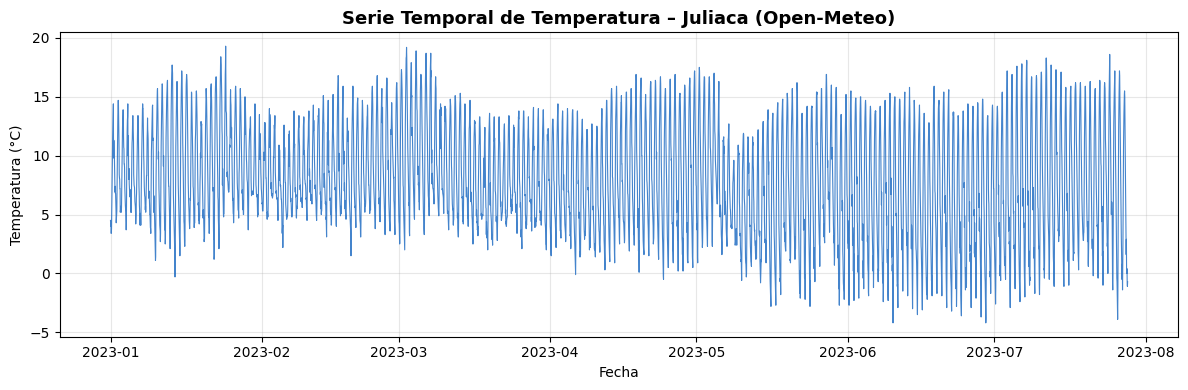

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(pdf["time"], pdf["temperature_2m"], color="#1565C0", linewidth=0.8, alpha=0.8)
plt.title("Serie Temporal de Temperatura – Juliaca (Open-Meteo)", fontsize=13, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Celda C – 2. Temperatura promedio por mes

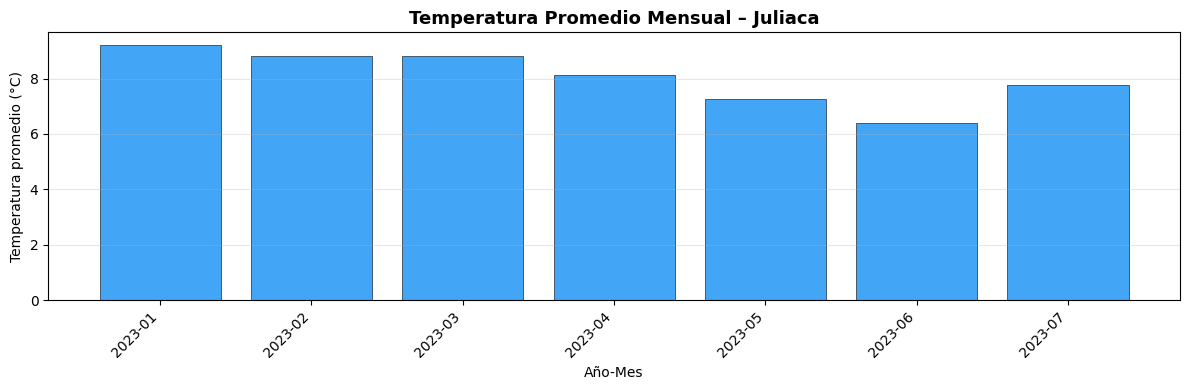

In [13]:
pdf["año_mes"] = pdf["time"].dt.to_period("M")
mensual = pdf.groupby("año_mes")["temperature_2m"].mean().reset_index()
mensual["año_mes"] = mensual["año_mes"].astype(str)

plt.figure(figsize=(12, 4))
plt.bar(mensual["año_mes"], mensual["temperature_2m"], color="#42A5F5", edgecolor="black", linewidth=0.4)
plt.title("Temperatura Promedio Mensual – Juliaca", fontsize=13, fontweight="bold")
plt.xlabel("Año-Mes")
plt.ylabel("Temperatura promedio (°C)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Celda D – 3. Distribución de temperatura

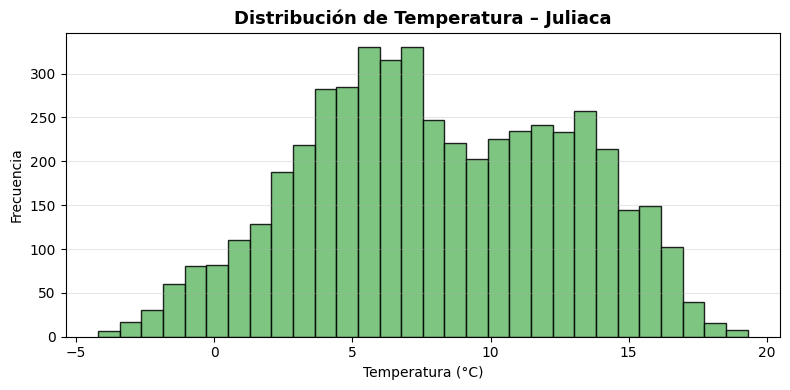

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(pdf["temperature_2m"], bins=30, color="#66BB6A", edgecolor="black", alpha=0.85)
plt.title("Distribución de Temperatura – Juliaca", fontsize=13, fontweight="bold")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Celda E – 4. Matriz de correlación

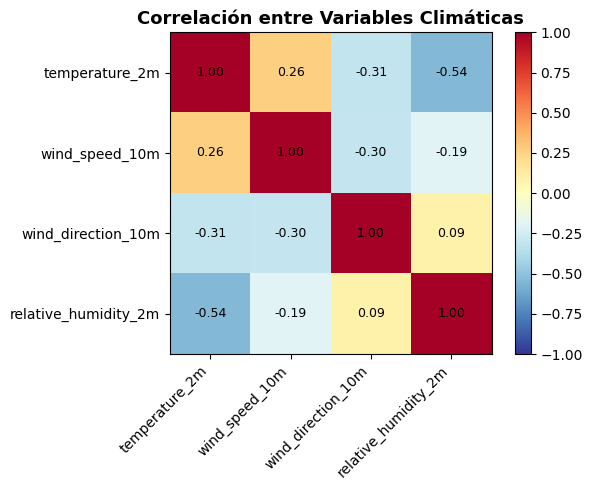

In [15]:
cols_corr = ["temperature_2m", "wind_speed_10m", "wind_direction_10m", "relative_humidity_2m"]
corr = pdf[cols_corr].corr()

plt.figure(figsize=(7, 5))
im = plt.imshow(corr, cmap="RdYlBu_r", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(cols_corr)), cols_corr, rotation=45, ha="right")
plt.yticks(range(len(cols_corr)), cols_corr)
plt.title("Correlación entre Variables Climáticas", fontsize=13, fontweight="bold")

# Anotar los valores
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

Celda F – 5. Real vs Predicho (del modelo)

In [23]:
# Usar las predicciones del modelo Random Forest ganador
pred_pdf = pred_rf.select("label", "prediction").sample(False, 0.3, seed=42).toPandas()

In [21]:
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "false")

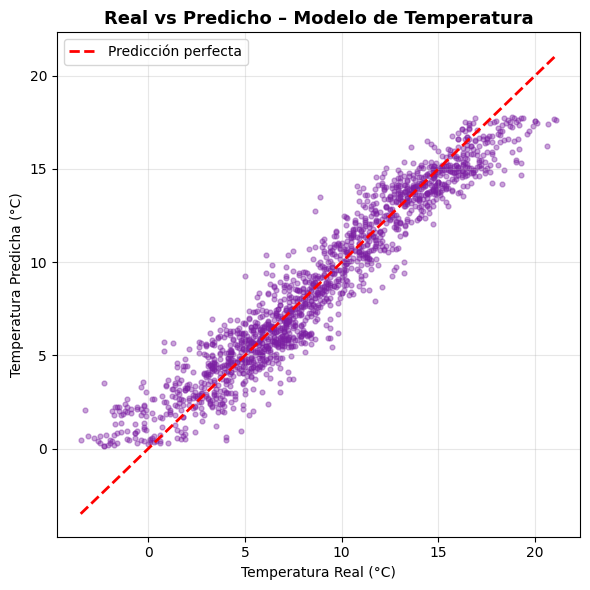

In [26]:
# Usa las predicciones del mejor modelo (ajusta el nombre si es necesario)
pred_pdf = pred_rf.select("label", "prediction").sample(False, 0.3, seed=42).toPandas()

plt.figure(figsize=(6, 6))
plt.scatter(pred_pdf["label"], pred_pdf["prediction"], alpha=0.4, s=12, color="#7B1FA2")
plt.plot([pred_pdf["label"].min(), pred_pdf["label"].max()],
         [pred_pdf["label"].min(), pred_pdf["label"].max()],
         color="red", linestyle="--", linewidth=2, label="Predicción perfecta")
plt.title("Real vs Predicho – Modelo de Temperatura", fontsize=13, fontweight="bold")
plt.xlabel("Temperatura Real (°C)")
plt.ylabel("Temperatura Predicha (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Celda G – 6. Importancia de variables (RandomForest)

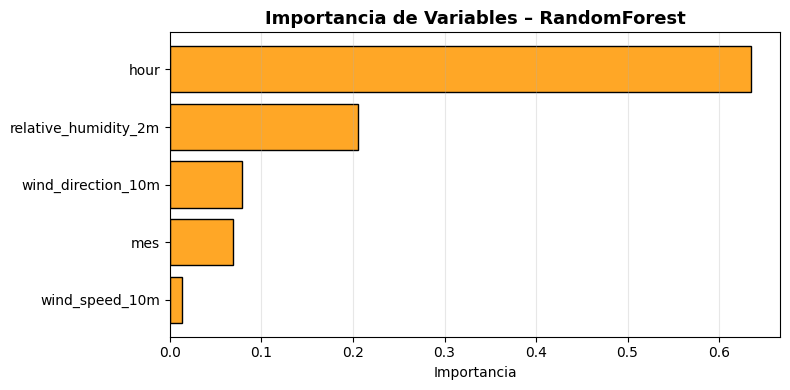

In [27]:
# Asegúrate de tener modelo_rf entrenado
importances = list(modelo_rf.featureImportances)
nombres = PREDICTORES

# Ordenar de mayor a menor
pares = sorted(zip(nombres, importances), key=lambda x: x[1], reverse=True)
nombres_ord, imps_ord = zip(*pares)

plt.figure(figsize=(8, 4))
bars = plt.barh(nombres_ord[::-1], imps_ord[::-1], color="#FFA726", edgecolor="black")
plt.title("Importancia de Variables – RandomForest", fontsize=13, fontweight="bold")
plt.xlabel("Importancia")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
plt.savefig("/opt/ecodata/artifacts/grafico_temperatura.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Celda 8 – Conclusiones

In [8]:
print("""
PIPELINE U1 COMPLETADO
- Arquitectura: Lambda
- Capa Gold: Parquet particionado por año/mes
- Controles: 0 nulos, 0 duplicados, PartitionFilters verificado
- Modelo: comparado (3 LR + RF) y guardado el ganador
""")


PIPELINE U1 COMPLETADO
- Arquitectura: Lambda
- Capa Gold: Parquet particionado por año/mes
- Controles: 0 nulos, 0 duplicados, PartitionFilters verificado
- Modelo: comparado (3 LR + RF) y guardado el ganador

